# System Vulnerabilities Analysis of Network #
## Targeted Attack vs Random Failure ##

Install Packages

In [1]:
import pandas as pd 
import geopandas as gpd
%pip install matplotlib 
import matplotlib.pyplot as plt
import networkx as nx
%pip install seaborn
import seaborn as sns 
import numpy as np
import networkit as nk

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Read in Data

In [2]:
# Load node list from CSV
# Assuming the CSV has columns: 'node_id' and optionally other attributes
node_csv_path = "node_list_dc_btwn.csv"
nodes_df = pd.read_csv(node_csv_path)

# Load edge list from CSV
# Assuming the CSV has columns: 'source', 'target' and optionally other attributes
edge_csv_path = "edge_list.csv"
edges_df = pd.read_csv(edge_csv_path)

In [3]:
# Assuming your DataFrame is named 'df' and the column containing betweenness centrality is named 'betweenness_centrality'

# Find the maximum and minimum values
max_value = nodes_df['Betweenness Centrality'].max()
min_value = nodes_df['Betweenness Centrality'].min()
avg_value = nodes_df['Betweenness Centrality'].mean()

# Print the results
print(f"Maximum Betweenness Centrality: {max_value}")
print(f"Minimum Betweenness Centrality: {min_value}")
print(f"Average Betweenness Centrality: {avg_value}")

Maximum Betweenness Centrality: 180918375.89595225
Minimum Betweenness Centrality: 0.0
Average Betweenness Centrality: 915947.3797754961


Build NetworkX Graph from NetworKit csv files

In [4]:
# Create an empty NetworkX graph
G = nx.Graph()

In [5]:
# Add nodes with attributes
for _, row in nodes_df.iterrows():
    node_id = row['Node ID']
    attributes = row.drop('Node ID').to_dict()  # Convert other columns to attributes
    G.add_node(node_id, **attributes)

# Add edges with attributes
for _, row in edges_df.iterrows():
    source = row['Source']
    target = row['Target']
    attributes = row.drop(['Source', 'Target']).to_dict()  # Convert other columns to attributes
    G.add_edge(source, target, **attributes)

# Verify the graph is created
print("Number of nodes in NetworkX graph:", G.number_of_nodes())
print("Number of edges in NetworkX graph:", G.number_of_edges())

Number of nodes in NetworkX graph: 21202
Number of edges in NetworkX graph: 32061


In [6]:
# Assuming 'G_sub_nx' is your NetworkX graph and betweenness centrality is already calculated as a node attribute

# Find the node with the maximum betweenness centrality
max_node = max(G.nodes, key=lambda node: G.nodes[node].get('Betweenness Centrality', 0))
max_value = G.nodes[max_node].get('Betweenness Centrality', 0)

# Print the results
print(f"Node with maximum betweenness centrality: {max_node}")
print(f"Maximum betweenness centrality value: {max_value}")

Node with maximum betweenness centrality: 15619.0
Maximum betweenness centrality value: 180918375.89595225


In [7]:
print(attributes.keys())

dict_keys(['Weight'])


In [8]:
# Convert DataFrame to a dictionary of dictionaries
attributes = nodes_df.set_index('Node ID').to_dict('index')

# Assign attributes to the graph
nx.set_node_attributes(G, attributes)

In [9]:
# Create a DataFrame from the NetworkX graph
nodes_df = pd.DataFrame(G.nodes(data=True), columns=['Node ID', 'Attributes'])
edges_df = pd.DataFrame(G.edges(data=True), columns=['Source', 'Target', 'Attributes'])

# Save the node and edge DataFrames to CSV
nodes_df.to_csv("nodes_nx.csv", index=False)
edges_df.to_csv("edges_nx.csv", index=False)

## Identify Largest Connected Component for Analysis

In [10]:
# Identify the largest connected component
largest_cc = max(nx.connected_components(G), key=len)

# Create a subgraph containing only the nodes in the largest connected component
G_sub_nx = G.subgraph(largest_cc).copy()  # Use `.copy()` to ensure it's a standalone graph

# Verify the node list remains the same
print("Number of nodes in NetworkX subgraph:", G_sub_nx.number_of_nodes())
print("Number of edges in NetworkX subgraph:", G_sub_nx.number_of_edges())

Number of nodes in NetworkX subgraph: 21197
Number of edges in NetworkX subgraph: 32057


Compare Metrics

In [11]:
print("Total Number of Edges in Network: ",G.number_of_edges())
print("Number of Edges in Subnetwork: ",G_sub_nx.number_of_edges())

Total Number of Edges in Network:  32061
Number of Edges in Subnetwork:  32057


In [12]:
print("Total Number of Nodes in Network: ",G.number_of_nodes())
print("Number of Nodes in Subnetwork: ",G_sub_nx.number_of_nodes())

Total Number of Nodes in Network:  21202
Number of Nodes in Subnetwork:  21197


In [13]:
print("Average degree of Network = ",2*G.number_of_edges()/G.number_of_nodes())
print("Average degree of Subnetwork = ",2*G_sub_nx.number_of_edges()/G_sub_nx.number_of_nodes())

Average degree of Network =  3.0243373266672955
Average degree of Subnetwork =  3.0246733028258714


In [14]:
# Compute clustering coefficient
clustering_coeffs = nx.clustering(G_sub_nx)
min_clustering = min(clustering_coeffs.values())
max_clustering = max(clustering_coeffs.values())
print(f"Minimum clustering coefficient: {min_clustering}")
print(f"Maximum clustering coefficient: {max_clustering}")
print("Average Clustering Coefficient of Network = ", nx.average_clustering(G))
print("Average Clustering Coefficient of Subnetwork = ", nx.average_clustering(G_sub_nx))

Minimum clustering coefficient: 0
Maximum clustering coefficient: 0.6666666666666666
Average Clustering Coefficient of Network =  0.029212091401979147
Average Clustering Coefficient of Subnetwork =  0.029218982021265362


In [15]:
# Compute degree
degrees = dict(G_sub_nx.degree())
min_degree = min(degrees.values())
max_degree = max(degrees.values())
print(f"Minimum degree: {min_degree}")
print(f"Maximum degree: {max_degree}")

Minimum degree: 1
Maximum degree: 8


In [ ]:
# # Compute shortest path length
# shortest_path_lengths = dict(nx.shortest_path_length(G_sub_nx))
# all_lengths = [length for target_lengths in shortest_path_lengths.values() for length in target_lengths.values()]
# min_shortest_path = min(all_lengths)
# max_shortest_path = max(all_lengths)
# print(f"Minimum shortest path length: {min_shortest_path}")
# print(f"Maximum shortest path length: {max_shortest_path}")

In [ ]:
# # Calculate the average shortest path length for the subgraph
# avg_shortest_path_length = nx.average_shortest_path_length(G_sub_nx)
# print("Average Shortest Path of Network =", avg_shortest_path_length)

In [16]:
# Assuming 'G_sub_nx' is your NetworkX graph and betweenness centrality is already calculated as a node attribute

# Find the node with the maximum betweenness centrality
max_node = max(G_sub_nx.nodes, key=lambda node: G_sub_nx.nodes[node].get('Betweenness Centrality', 0))
max_value = G_sub_nx.nodes[max_node].get('Betweenness Centrality', 0)

# Print the results
print(f"Node with maximum betweenness centrality: {max_node}")
print(f"Maximum betweenness centrality value: {max_value}")

Node with maximum betweenness centrality: 15619.0
Maximum betweenness centrality value: 180918375.89595225


In [17]:
# Create a DataFrame from the subgraph
nodes_df_sub = pd.DataFrame(G_sub_nx.nodes(data=True), columns=['Node ID', 'Attributes'])
edges_df_sub = pd.DataFrame(G_sub_nx.edges(data=True), columns=['Source', 'Target', 'Attributes'])

# Save the subgraph node and edge DataFrames to CSV
nodes_df_sub.to_csv("nodes_nx_sub.csv", index=False)
edges_df_sub.to_csv("edges_nx_sub.csv", index=False)

# Targetted Attacks ##

Nodes sorted by Degree for Subnetwork

In [18]:
N = G_sub_nx.number_of_nodes()
number_of_steps = N
M = N // number_of_steps

num_nodes_removed = range(0, N, M)

# Run targeted attack by degree 10 times
num_runs = 10
all_degree_attack_runs = []
fraction_nodes_removed = []

for run in range(num_runs):
    C = G_sub_nx.copy()
    targeted_attack_core_proportions_d = []
    
    for nodes_removed in num_nodes_removed:
        # Measure the relative size of the network core
        core = max(nx.connected_components(C), key=len)

        core_proportion = len(core) / N
        targeted_attack_core_proportions_d.append(core_proportion)
        
        # Only add to fraction_nodes_removed once (same for all runs)
        if run == 0:
            fraction_nodes_removed.append(nodes_removed / N)

        # If there are more than M nodes, select top M nodes and remove them
        if C.number_of_nodes() > M:
            nodes_sorted_by_degree = sorted(C.nodes, key=C.degree, reverse=True)
            nodes_to_remove = nodes_sorted_by_degree[:M]
            C.remove_nodes_from(nodes_to_remove)
    
    all_degree_attack_runs.append(targeted_attack_core_proportions_d)

# Calculate mean and standard deviation across all runs
targeted_attack_core_proportions_d_mean = np.mean(all_degree_attack_runs, axis=0)
targeted_attack_core_proportions_d_std = np.std(all_degree_attack_runs, axis=0)

print(f"Completed {num_runs} degree-based targeted attack simulations")
print(f"Mean core proportion: {targeted_attack_core_proportions_d_mean}")

# Keep the original for backward compatibility
targeted_attack_core_proportions_d = targeted_attack_core_proportions_d_mean

Completed 10 degree-based targeted attack simulations
Mean core proportion: [1.00000000e+00 9.99952824e-01 9.99905647e-01 ... 4.71764872e-05
 4.71764872e-05 4.71764872e-05]


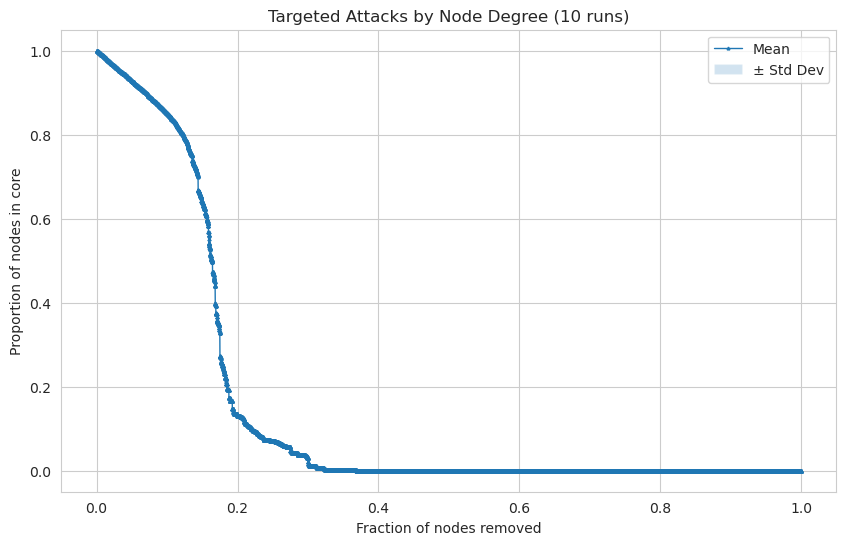

In [19]:
plt.figure(figsize=(10, 6))
plt.title('Targeted Attacks by Node Degree (10 runs)')
plt.xlabel('Fraction of nodes removed')
plt.ylabel('Proportion of nodes in core')
plt.plot(fraction_nodes_removed, targeted_attack_core_proportions_d_mean, marker='^', label='Mean', markersize=2, linewidth=1)
plt.fill_between(fraction_nodes_removed, 
                 targeted_attack_core_proportions_d_mean - targeted_attack_core_proportions_d_std,
                 targeted_attack_core_proportions_d_mean + targeted_attack_core_proportions_d_std,
                 alpha=0.2, label='± Std Dev')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
# Save results to CSV file
results_deg_df = pd.DataFrame({
    'Fraction of Nodes Removed': fraction_nodes_removed,
    'Mean Core Proportion': targeted_attack_core_proportions_d_mean,
    'Std Dev Core Proportion': targeted_attack_core_proportions_d_std
})
results_deg_df.to_csv('TA-Degree.csv', index=False)

In [ ]:
# Print value of M
print("Value of M:", M)

In [ ]:
# Calculate the number of nodes removed in first 3 steps
num_nodes_removed_first_3_steps = 3 * M
print("Number of nodes removed in first 3 steps:", num_nodes_removed_first_3_steps)

### Nodes sorted by Betweenness Centrality for Subnetwork ###
Static Prioritization: Betweenness Centrality ranked only at beginning, no dynamic updates

In [ ]:
# Adopted code from Marta
# Assuming betweenness centrality values are stored in the `attributes` dictionary
N = G_sub_nx.number_of_nodes()
number_of_steps = N
M = N // number_of_steps

num_nodes_removed = range(0, N, M)
C = G_sub_nx.copy()
targeted_attack_core_proportions_btwn = []
fraction_nodes_removed = []

############# Check the copy
# Convert nodes to DataFrame
nodes_df_sub = pd.DataFrame(C.nodes(data=True), columns=['Node ID', 'Attributes'])

# Expand attribute dictionary into separate columns
nodes_df_sub = nodes_df_sub.join(pd.json_normalize(nodes_df_sub.pop("Attributes")))

# Sort by "Betweenness Centrality" in descending order
nodes_df_sub = nodes_df_sub.sort_values(by="Betweenness Centrality", ascending=False)

# Save to CSV
nodes_df_sub.to_csv("copy_nodes_nx_sub.csv", index=False)

# Convert edges to DataFrame (unchanged)
edges_df_sub = pd.DataFrame(C.edges(data=True), columns=['Source', 'Target', 'Attributes'])
edges_df_sub = edges_df_sub.join(pd.json_normalize(edges_df_sub.pop("Attributes")))
edges_df_sub.to_csv("copy_edges_nx_sub.csv", index=False)

for nodes_removed in num_nodes_removed:
    # Measure the relative size of the network core
    core = max(nx.connected_components(C), key=len)
    core_proportion = len(core) / N

    # Save the largest connected component (core) nodes and edges to CSV
    C_core = C.subgraph(core).copy()  # Create a subgraph of the largest connected component

    # Save core nodes to CSV
    core_nodes_df = pd.DataFrame(C_core.nodes(data=True), columns=['Node ID', 'Attributes'])
    core_nodes_df = core_nodes_df.join(pd.json_normalize(core_nodes_df.pop("Attributes")))

    # Calculate log of betweenness centrality
    if 'Betweenness Centrality' in core_nodes_df.columns:
        core_nodes_df['Log Betweenness Centrality'] = np.log(core_nodes_df['Betweenness Centrality'].replace(0, np.nan))

    core_nodes_df.to_csv(f"TA_Core_Nodes/core_nodes_{nodes_removed}.csv", index=False)

    # Save core edges to CSV
    core_edges_df = pd.DataFrame(C_core.edges(data=True), columns=['Source', 'Target', 'Attributes'])
    core_edges_df = core_edges_df.join(pd.json_normalize(core_edges_df.pop("Attributes")))
    core_edges_df.to_csv(f"TA_Core_Edges/core_edges_{nodes_removed}.csv", index=False)

    targeted_attack_core_proportions_btwn.append(core_proportion)
    fraction_nodes_removed.append(nodes_removed / N)
    print(nodes_removed,core_proportion)

    # If there are more than M nodes, select top M nodes by betweenness centrality and remove them
    if C.number_of_nodes() > M:
        # Ensure node IDs match the keys in the attributes dictionary
        nodes_sorted_by_betweenness = sorted(
            C.nodes, 
            key=lambda node: attributes[int(node)]['Betweenness Centrality'],  # Convert node ID to int if necessary
            reverse=True
        )
        nodes_to_remove = nodes_sorted_by_betweenness[:M]
        C.remove_nodes_from(nodes_to_remove)        

    # Save removed nodes and their attributes to a csv file
        removed_nodes_data = []
        # Create a DataFrame with Node ID, Betweenness Centrality, Coordinates, and Step
        for node in nodes_to_remove:
            removed_nodes_data.append({
                "Node ID": node,
                "Betweenness Centrality": attributes[int(node)]['Betweenness Centrality'],
                "Longitude": attributes[int(node)]['Longitude'],
                "Latitude": attributes[int(node)]['Latitude'],
                "Step": nodes_removed
            })
        removed_nodes_df = pd.DataFrame(removed_nodes_data)
        removed_nodes_df.to_csv(f"TargetAttack_Removal/TA_removed_nodes_{nodes_removed}.csv", index=False)

# Save the results to a CSV file
results_btwn_df = pd.DataFrame({
    'Fraction of Nodes Removed': fraction_nodes_removed,
    'Core Proportion': targeted_attack_core_proportions_btwn
})
results_btwn_df.to_csv('TA-BC-Static.csv', index=False)

# Plotting the results
plt.title('Targeted Attacks by Betweenness Centrality')
plt.xlabel('Fraction of nodes removed')
plt.ylabel('Proportion of nodes in core')
plt.plot(fraction_nodes_removed, targeted_attack_core_proportions_btwn, marker='^', markersize=2)
plt.grid(True)
plt.show()

In [ ]:
# Check the top 10 nodes by betweenness centrality in subgraph G_sub_nx
top_10_nodes = sorted(G_sub_nx.nodes, key=lambda node: G_sub_nx.nodes[node].get('Betweenness Centrality', 0), reverse=True)[:10]
print("Top 10 nodes by betweenness centrality in subgraph G_sub_nx:")
for node in top_10_nodes:
    print(f"Node ID: {node}, Betweenness Centrality: {G_sub_nx.nodes[node].get('Betweenness Centrality', 0)}")

In [ ]:
# Check the top 10 nodes by betweenness centrality in subgraph C_core
top_10_nodes = sorted(C_core.nodes, key=lambda node: C_core.nodes[node].get('Betweenness Centrality', 0), reverse=True)[:10]
print("Top 10 nodes by betweenness centrality in subgraph C_core:")
for node in top_10_nodes:
    print(f"Node ID: {node}, Betweenness Centrality: {C_core.nodes[node].get('Betweenness Centrality', 0)}")

In [ ]:
# Check the top 10 nodes by betweenness centrality in graph C
top_10_nodes = sorted(C.nodes, key=lambda node: C.nodes[node].get('Betweenness Centrality', 0), reverse=True)[:10]
print("Top 10 nodes by betweenness centrality in graph C:")
for node in top_10_nodes:
    print(f"Node ID: {node}, Betweenness Centrality: {C.nodes[node].get('Betweenness Centrality', 0)}")

### Nodes sorted by Betweenness Centrality for Subnetwork ###
Dynamic Prioritization: Betweenness Centrality Recomputed after Each Node Removal Step

In [ ]:
# Adopted code from Marta
# Recompute betweenness centrality of remaining largest connected component after each node removal
N = G_sub_nx.number_of_nodes()
number_of_steps = N
M = N // number_of_steps

num_nodes_removed = range(0, N, M)
C = G_sub_nx.copy()
targeted_attack_core_proportions_btwn_dyn = []
fraction_nodes_removed = []

############# Check the copy
# Convert nodes to DataFrame
nodes_df_sub = pd.DataFrame(C.nodes(data=True), columns=['Node ID', 'Attributes'])

# Expand attribute dictionary into separate columns
nodes_df_sub = nodes_df_sub.join(pd.json_normalize(nodes_df_sub.pop("Attributes")))

# Sort by "Betweenness Centrality" in descending order
nodes_df_sub = nodes_df_sub.sort_values(by="Betweenness Centrality", ascending=False)

# Save to CSV
nodes_df_sub.to_csv("copy_nodes_nx_sub_dyn.csv", index=False)

# Convert edges to DataFrame (unchanged)
edges_df_sub = pd.DataFrame(C.edges(data=True), columns=['Source', 'Target', 'Attributes'])
edges_df_sub = edges_df_sub.join(pd.json_normalize(edges_df_sub.pop("Attributes")))
edges_df_sub.to_csv("copy_edges_nx_sub_dyn.csv", index=False)

for nodes_removed in num_nodes_removed:
    # Measure the relative size of the network core
    core = max(nx.connected_components(C), key=len)
    core_proportion = len(core) / N

    # Save the largest connected component (core) nodes and edges to CSV
    C_core = C.subgraph(core).copy()  # Create a subgraph of the largest connected component

    # Save core nodes to CSV
    core_nodes_df = pd.DataFrame(C_core.nodes(data=True), columns=['Node ID', 'Attributes'])
    core_nodes_df = core_nodes_df.join(pd.json_normalize(core_nodes_df.pop("Attributes")))

    # Calculate log of betweenness centrality
    if 'Betweenness Centrality' in core_nodes_df.columns:
        core_nodes_df['Log Betweenness Centrality'] = np.log(core_nodes_df['Betweenness Centrality'].replace(0, np.nan))

    core_nodes_df.to_csv(f"TA_Core_Nodes-Dynamic/core_nodes_{nodes_removed}.csv", index=False)

    # Save core edges to CSV
    core_edges_df = pd.DataFrame(C_core.edges(data=True), columns=['Source', 'Target', 'Attributes'])
    core_edges_df = core_edges_df.join(pd.json_normalize(core_edges_df.pop("Attributes")))
    core_edges_df.to_csv(f"TA_Core_Edges-Dynamic/core_edges_{nodes_removed}.csv", index=False)

    targeted_attack_core_proportions_btwn_dyn.append(core_proportion)
    fraction_nodes_removed.append(nodes_removed / N)
    print(nodes_removed,core_proportion)

    # If there are more than M nodes, recompute betweenness centrality and select top M nodes to remove
    if C.number_of_nodes() > M:
        # Convert current graph from NetworkX to NetworKit
        C_nk = nk.nxadapter.nx2nk(C)
        
        # Recompute approximate betweenness centrality for the current graph
        btwn_approx = nk.centrality.ApproxBetweenness(C_nk, epsilon=0.01)
        btwn_approx.run()
        current_bc_scores = btwn_approx.scores()
        
        # Align scores back to original NetworkX node labels using current ordering
        node_order = list(C.nodes())
        current_bc = dict(zip(node_order, current_bc_scores))
        
        # Get nodes sorted by updated betweenness centrality in descending order
        nodes_sorted_by_betweenness = sorted(
            C.nodes, 
            key=lambda node: current_bc[node],
            reverse=True
        )
        nodes_to_remove = nodes_sorted_by_betweenness[:M]
        C.remove_nodes_from(nodes_to_remove)        

    # Save removed nodes and their attributes to a csv file
        removed_nodes_data = []
        # Create a DataFrame with Node ID, Betweenness Centrality, Coordinates, and Step
        for node in nodes_to_remove:
            removed_nodes_data.append({
                "Node ID": node,
                "Betweenness Centrality": current_bc[node],
                "Longitude": attributes[int(node)]['Longitude'],
                "Latitude": attributes[int(node)]['Latitude'],
                "Step": nodes_removed
            })
        removed_nodes_df = pd.DataFrame(removed_nodes_data)
        removed_nodes_df.to_csv(f"TargetAttack_Removal-Dynamic/TA_removed_nodes_{nodes_removed}.csv", index=False)

# Save the results to a CSV file
results_btwn_dyn_df = pd.DataFrame({
    'Fraction of Nodes Removed': fraction_nodes_removed,
    'Core Proportion': targeted_attack_core_proportions_btwn_dyn
})
results_btwn_dyn_df.to_csv('TA-BC-Dynamic.csv', index=False)

# Plotting the results
plt.title('Targeted Attacks by Betweenness Centrality (Dynamically Recomputed)')
plt.xlabel('Fraction of nodes removed')
plt.ylabel('Proportion of nodes in core')
plt.plot(fraction_nodes_removed, targeted_attack_core_proportions_btwn_dyn, marker='^', markersize=2)
plt.grid(True)
plt.show()

## Random Attack

In [ ]:
import random

In [ ]:
# Adopt code from Marta

N = G_sub_nx.number_of_nodes()
number_of_steps = N
M = N // number_of_steps

num_nodes_removed = range(0, N, M)
C = G_sub_nx.copy()

print(M)

random_attack_core_proportions = []
fraction_nodes_removed = []
for nodes_removed in num_nodes_removed:
    # Measure the relative size of the network core
    core = max(nx.connected_components(C), key=len)
    core_proportion = len(core) / N
    
    # Save the largest connected component (core) nodes and edges to CSV
    C_core = C.subgraph(core).copy()  # Create a subgraph of the largest connected component

    # Save core nodes to CSV
    core_nodes_df = pd.DataFrame(C_core.nodes(data=True), columns=['Node ID', 'Attributes'])
    core_nodes_df = core_nodes_df.join(pd.json_normalize(core_nodes_df.pop("Attributes")))
    core_nodes_df.to_csv(f"RA_Core_Nodes/RA_core_nodes_{nodes_removed}.csv", index=False)

    # Save core edges to CSV
    core_edges_df = pd.DataFrame(C_core.edges(data=True), columns=['Source', 'Target', 'Attributes'])
    core_edges_df = core_edges_df.join(pd.json_normalize(core_edges_df.pop("Attributes")))
    core_edges_df.to_csv(f"RA_Core_Edges/RA_core_edges_{nodes_removed}.csv", index=False)

    random_attack_core_proportions.append(core_proportion)
    fraction_nodes_removed.append(nodes_removed / N)
    print(nodes_removed,core_proportion)

    # If there are more than M nodes, select M nodes at random and remove them
    if C.number_of_nodes() > M:
        nodes_to_remove = random.sample(list(C.nodes), M)
        C.remove_nodes_from(nodes_to_remove)

    # Save removed nodes and their attributes to a csv file
        removed_nodes_data = []
        # Create a DataFrame with Node ID, Betweenness Centrality, Coordinates, and Step
        for node in nodes_to_remove:
            removed_nodes_data.append({
                "Node ID": node,
                "Betweenness Centrality": attributes[int(node)]['Betweenness Centrality'],
                "Longitude": attributes[int(node)]['Longitude'],
                "Latitude": attributes[int(node)]['Latitude'],
                "Step": nodes_removed
            })
        removed_nodes_df = pd.DataFrame(removed_nodes_data)
        removed_nodes_df.to_csv(f"RandomAttack_Removal/RA_removed_nodes_{nodes_removed}.csv", index=False)



In [ ]:
# Plot Random Attack results
plt.title('Random Attacks')
plt.xlabel('Fraction of nodes removed')
plt.ylabel('Proportion of nodes in core')
plt.plot(fraction_nodes_removed, random_attack_core_proportions, marker='o', markersize=2)
plt.grid(True)
plt.show()

In [ ]:
# Repeated Random Attack for confidence interval

N = G_sub_nx.number_of_nodes()
number_of_steps = N
M = N // number_of_steps

num_nodes_removed = range(0, G_sub_nx.number_of_nodes(), M)

# Run random attack 10 times
num_runs = 10
all_random_attack_runs = []
fraction_nodes_removed = []

for run in range(num_runs):
    C = G_sub_nx.copy()
    random_attack_core_proportions = []
    
    for nodes_removed in num_nodes_removed:
        # Measure the relative size of the network core
        core = max(nx.connected_components(C), key=len)
        core_proportion = len(core) / N
        random_attack_core_proportions.append(core_proportion)
        
        # Only add to fraction_nodes_removed once (same for all runs)
        if run == 0:
            fraction_nodes_removed.append(nodes_removed / N)

        # If there are more than M nodes, select M nodes at random and remove them
        if C.number_of_nodes() > M:
            nodes_to_remove = random.sample(list(C.nodes), M)
            C.remove_nodes_from(nodes_to_remove)
    
    all_random_attack_runs.append(random_attack_core_proportions)

# Calculate mean and standard deviation across all runs
random_attack_core_proportions_mean = np.mean(all_random_attack_runs, axis=0)
random_attack_core_proportions_std = np.std(all_random_attack_runs, axis=0)

print(f"Completed {num_runs} random attack simulations")
print(f"Mean core proportion: {random_attack_core_proportions_mean}")


In [ ]:
plt.figure(figsize=(10, 6))
plt.title('Random Failure (10 runs)')
plt.xlabel('Fraction of nodes removed')
plt.ylabel('Proportion of nodes in core')
plt.plot(fraction_nodes_removed, random_attack_core_proportions_mean, marker='o', label='Mean', markersize=1, linewidth=1)
plt.fill_between(fraction_nodes_removed, 
                 random_attack_core_proportions_mean - random_attack_core_proportions_std,
                 random_attack_core_proportions_mean + random_attack_core_proportions_std,
                 alpha=0.2, label='± Std Dev')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Save plot data to CSV
random_attack_results_df = pd.DataFrame({
    'Fraction of Nodes Removed': fraction_nodes_removed,
    'Mean Core Proportion': random_attack_core_proportions_mean,
    'Std Dev Core Proportion': random_attack_core_proportions_std
})
random_attack_results_df.to_csv('RA-Results.csv', index=False)

## Plot Comparisons ##

In [ ]:
# Truncate to match lengths
min_length = min(len(targeted_attack_core_proportions_btwn), len(targeted_attack_core_proportions_d), len(random_attack_core_proportions_mean), len(targeted_attack_core_proportions_btwn_dyn))
random_attack_mean_trim = random_attack_core_proportions_mean[:min_length]
targeted_attack_btwn_trim = targeted_attack_core_proportions_btwn[:min_length]
targeted_attack_deg_trim = targeted_attack_core_proportions_d[:min_length]
targeted_attack_btwn_dyn_trim = targeted_attack_core_proportions_btwn_dyn[:min_length]

Targeted Attack by Betweenness Centrality vs Random 

In [ ]:
plt.figure(figsize=(10, 6))
plt.xlabel('Fraction of nodes removed')
plt.ylabel('Proportion of nodes in core')
plt.title('Random Failure vs. Targeted Attack by Betweenness Centrality')
plt.plot(fraction_nodes_removed, random_attack_mean_trim, marker='o', label='Random Failures', markersize=2)
plt.plot(fraction_nodes_removed, targeted_attack_btwn_trim, marker='^', label='Targeted Attacks (Static BC)', markersize=2)
plt.plot(fraction_nodes_removed, targeted_attack_btwn_dyn_trim, marker='d', label='Targeted Attacks (Dynamic BC)', markersize=2)
plt.grid(True)
plt.legend()
plt.show()

Targeted Attack by Degree vs Random Failure

In [ ]:
plt.xlabel('Fraction of nodes removed')
plt.ylabel('Proportion of nodes in core')
plt.title('Random Failure vs. Targeted Attack by Degree')
plt.plot(fraction_nodes_removed, random_attack_mean_trim, marker='o', label='Random Failures', markersize=2)
plt.plot(fraction_nodes_removed, targeted_attack_deg_trim, marker='^', label='Targeted Attacks', markersize=2)
plt.legend()

In [ ]:
# Plot all attacks
plt.xlabel('Fraction of nodes removed')
plt.ylabel('Proportion of nodes in core')
plt.title('Targeted Attacks vs Random Failure')
plt.plot(fraction_nodes_removed, targeted_attack_btwn_trim, marker='o', label='Static BC', markersize=2)
plt.plot(fraction_nodes_removed, targeted_attack_deg_trim, marker='^', label='Degree', markersize=2)
plt.plot(fraction_nodes_removed, random_attack_mean_trim, marker='s', label='Random', markersize=2)
plt.plot(fraction_nodes_removed, targeted_attack_btwn_dyn_trim, marker='d', label='Dynamic BC', markersize=2)
plt.legend()